In [21]:
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

import utils as ut

In [9]:
df_itc_all, dict_info = ut.load_itc_dataset("full")

In [10]:
df_itc_all["r-l-v"] = df_itc_all["right_val"] - df_itc_all["left_val"]
df_itc_all["r-l-v-log"] = np.log(df_itc_all["right_val"]) - np.log(df_itc_all["left_val"])
df_itc_all["r-l-t"] = df_itc_all["right_time"] - df_itc_all["left_time"]
np.corrcoef(df_itc_all["r-l-v-log"], df_itc_all["r-l-t"])

array([[1.        , 0.47049261],
       [0.47049261, 1.        ]])

In [11]:
df_itc_all["sooner_picked"] = (((df_itc_all["right_picked"] == 1) & (df_itc_all["r-l-t"] < 0)) | ((df_itc_all["right_picked"] == 0) & (df_itc_all["r-l-t"] > 0))).astype(int)
df_itc_all["later_picked"] = (((df_itc_all["right_picked"] == 1) & (df_itc_all["r-l-t"] > 0)) | ((df_itc_all["right_picked"] == 0) & (df_itc_all["r-l-t"] < 0))).astype(int)

df_itc_all["moreval_picked"] = (((df_itc_all["right_picked"] == 1) & (df_itc_all["r-l-v"] > 0)) | ((df_itc_all["right_picked"] == 0) & (df_itc_all["r-l-v"] < 0))).astype(int)
df_itc_all["lessval_picked"] = (((df_itc_all["right_picked"] == 1) & (df_itc_all["r-l-v"] < 0)) | ((df_itc_all["right_picked"] == 0) & (df_itc_all["r-l-v"] > 0))).astype(int)

In [22]:
df_itc_all["r-l-v-z"] = df_itc_all[["r-l-v"]].apply(zscore)
df_itc_all["r-l-t-z"] = df_itc_all[["r-l-t"]].apply(zscore)
df_itc_all["absolute_time_diff"] = np.abs(df_itc_all["r-l-t"])
df_itc_all["relative_time_diff"] = df_itc_all["time_diff"] / ((df_itc_all["right_time"] + df_itc_all["left_time"]) / 2)

Correlation between money and time differences are 0, only correlation between absolute and relative time diff

In [24]:
np.corrcoef(df_itc_all[["absolute_value_diff", "relative_value_diff", "absolute_time_diff", "relative_time_diff"]].T).round(3)

array([[ 1.   ,  0.005,  0.001,  0.001],
       [ 0.005,  1.   , -0.   , -0.001],
       [ 0.001, -0.   ,  1.   ,  0.467],
       [ 0.001, -0.001,  0.467,  1.   ]])

In [31]:
df_itc_all["t-diff-bin-label"] = pd.qcut(df_itc_all["r-l-t"].abs(), 5)
df_itc_all["t-diff-bin-nr"] = pd.qcut(df_itc_all["r-l-t"].abs(), 5, labels=False)
df_itc_all["v-diff-bin-label"] = pd.qcut(df_itc_all["r-l-v"].abs(), 5)
df_itc_all["v-diff-bin-nr"] = pd.qcut(df_itc_all["r-l-v"].abs(), 5, labels=False)

In [32]:
df_sooner_sid = df_itc_all.groupby(["sid_unique", "t-diff-bin-nr"])["sooner_picked"].agg(["count", "mean", "std"]).reset_index()
df_more_sid = df_itc_all.groupby(["sid_unique", "v-diff-bin-nr"])["moreval_picked"].agg(["count", "mean", "std"]).reset_index()

In [33]:
np.random.seed(86)
sids_sample = df_itc_all["sid_unique"].drop_duplicates().sample(9)
#sids_sample = np.arange(16, 42, 1)

In [34]:
t_labels = [str(l) for l in df_itc_all["t-diff-bin-label"].cat.categories]
v_labels = [str(l) for l in df_itc_all["v-diff-bin-label"].cat.categories]

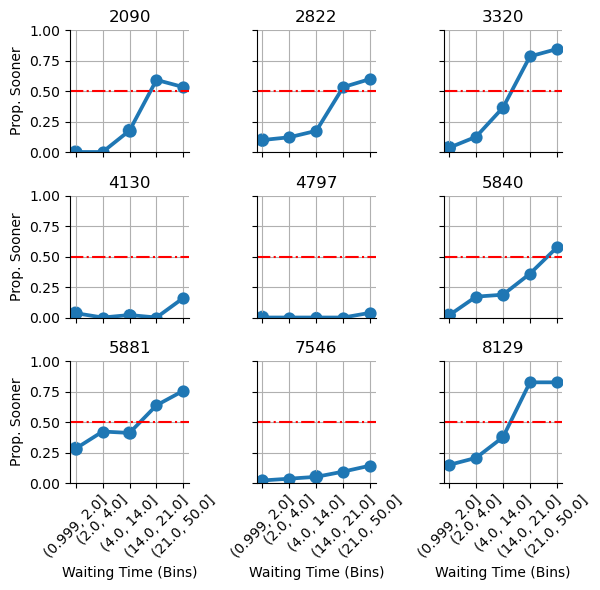

In [40]:
df_sample_tdiff = df_sooner_sid[df_sooner_sid["sid_unique"].isin(sids_sample)]

g = sns.FacetGrid(df_sample_tdiff, col = "sid_unique", col_wrap = 3, ylim=(0, 1), height=2)

g.map_dataframe(
    sns.pointplot,
    x="t-diff-bin-nr",
    y="mean"
)
g.map_dataframe(
    sns.scatterplot,
    x="t-diff-bin-nr",
    y="mean",
    size="count",
    sizes=(5, 100)
)

# Clean facet titles
for ax in g.axes.flatten():
    title = ax.get_title()
    value = title.split(" = ")[1]
    ax.set_title(value)
    ax.grid(True)
    
g.set_ylabels("Prop. Sooner")
g.set_xlabels("Waiting Time (Bins)")

# Get all axes in a flat list
axes = g.axes.flatten()

# Identify how many columns the grid has
ncols = g._ncol

# Axes belonging to the last row
last_row_axes = axes[-ncols:]

# Apply xticks only to the last row
for ax in last_row_axes:
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(t_labels, rotation=45)


_ = g.map(plt.axhline, y=.5, linestyle="dashdot", c="red")
g.fig.savefig("figures/change-time-diff-sample.pdf", dpi=300, bbox_inches="tight")

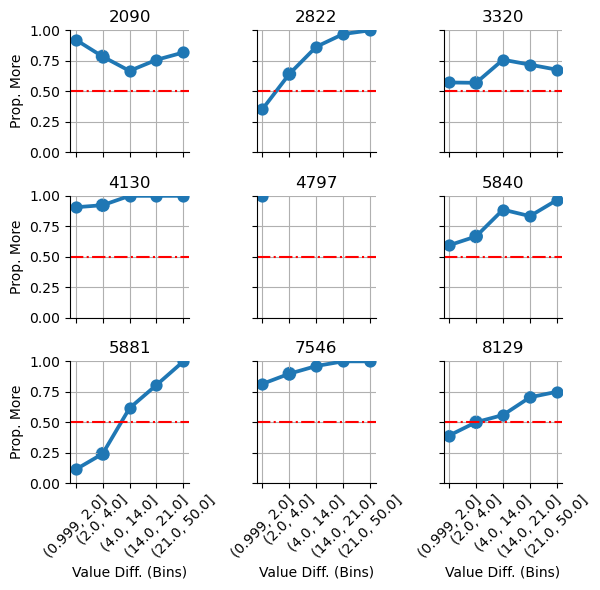

In [39]:
df_sample_valdiff = df_more_sid[df_more_sid["sid_unique"].isin(sids_sample)]
g = sns.FacetGrid(df_sample_valdiff, col = "sid_unique", col_wrap = 3, ylim=(0, 1), height=2)
g.map_dataframe(
    sns.pointplot,
    x="v-diff-bin-nr",
    y="mean",
)
g.map_dataframe(
    sns.scatterplot,
    x="v-diff-bin-nr",
    y="mean",
    size="count",
    sizes=(5, 100)
)

# Clean facet titles
for ax in g.axes.flatten():
    title = ax.get_title()
    value = title.split(" = ")[1]
    ax.set_title(value)
    ax.grid(True)
    
g.set_ylabels("Prop. More")
g.set_xlabels("Value Diff. (Bins)")

# Get all axes in a flat list
axes = g.axes.flatten()

# Identify how many columns the grid has
ncols = g._ncol

# Axes belonging to the last row
last_row_axes = axes[-ncols:]

# Apply xticks only to the last row
for ax in last_row_axes:
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(t_labels, rotation=45)

g.map(plt.axhline, y=.5, linestyle="dashdot", c="red")

g.fig.savefig("figures/change-value-diff-sample.pdf", dpi=300, bbox_inches="tight")

In [41]:
import statsmodels.formula.api as smf

In [42]:
df_itc_all.to_csv("data/itc-processed.csv")

In [43]:
df_itc_t_group = df_itc_all.groupby(["sid_unique", "t-diff-bin-nr"])["sooner_picked"].mean().reset_index()
df_itc_v_group = df_itc_all.groupby(["sid_unique", "v-diff-bin-nr"])["sooner_picked"].mean().reset_index()
df_itc_t_group["t-diff-bin-nr"] = df_itc_t_group["t-diff-bin-nr"] - 2
df_itc_v_group["v-diff-bin-nr"] = df_itc_v_group["v-diff-bin-nr"] - 2

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
def change_one_subject(idx_subject):

    # time model
    df_subject_time = df_itc_t_group.query(f"""sid_unique == {idx_subject}""")
    m_t = LinearRegression()
    m_t.fit(df_subject_time[["t-diff-bin-nr"]], df_subject_time["sooner_picked"])
    t_lo_hi = np.array([m_t.intercept_ - 2*m_t.coef_, m_t.intercept_ + 2*m_t.coef_])
    t_lo_hi_rounded = t_lo_hi.round(0)
    is_t_change = (t_lo_hi_rounded[0] != t_lo_hi_rounded[1]).astype(int).item()

    # value model
    df_subject_value = df_itc_v_group.query(f"""sid_unique == {idx_subject}""")
    m_v = LinearRegression()
    m_v.fit(df_subject_value[["v-diff-bin-nr"]], df_subject_value["sooner_picked"])
    v_lo_hi = np.array([m_v.intercept_ - 2*m_v.coef_, m_v.intercept_ + 2*m_v.coef_])
    v_lo_hi_rounded = v_lo_hi.round(0)
    is_v_change = (v_lo_hi_rounded[0] != v_lo_hi_rounded[1]).astype(int).item()

    
    return idx_subject, is_t_change, is_v_change

In [46]:
l_subjects = df_itc_all["sid_unique"].drop_duplicates()#.head(100)
l_models = list(map(change_one_subject, l_subjects))

In [61]:
df_changes = pd.DataFrame(np.array(l_models), columns=["sid_unique", "Time Change", "Value Change"])
df_change_counts = df_changes[["Time Change", "Value Change"]].agg(["count", "mean"]).reset_index(drop=True).transpose()
df_change_counts = df_change_counts.reset_index()
df_change_counts.columns = ["Change Type", "Nr. Subjects", "Prop. Changes"]
df_change_counts["Nr. Changes"] = df_change_counts["Nr. Subjects"] * df_change_counts["Prop. Changes"]
df_change_counts["Nr. Changes"] = df_change_counts["Nr. Changes"].astype(int)
df_change_counts["Nr. Subjects"] = df_change_counts["Nr. Subjects"].astype(int)
df_change_counts.round(3)

,Change Type,Nr. Subjects,Prop. Changes,Nr. Changes
0,Time Change,9062,0.289,2616
1,Value Change,9062,0.173,1568
